# DMFC-FAS

https://github.com/sheriff1max/DMFC-FAS/tree/master

In [1]:
def hour2sec(hour: float) -> float:
    return hour * 60 * 60

In [2]:
PARAMS = {
    'domain': 'figure',  # cutout | figure | mannequin | mask | print | screen
    'description': 'DMFC-FAS',
    'direction': 'maximize',

    'n_trials': 500,
    'timeout': hour2sec(7),  # нужно в секундах
}


_domains = ['cutout', 'figure', 'mannequin', 'mask', 'print', 'screen']
PARAMS['exclude_folders'] = [domain for domain in _domains if domain != PARAMS['domain']]
print(f"{PARAMS['exclude_folders'] = }")

PARAMS['description'] += f' domain={PARAMS["domain"]}'
print(f"{PARAMS['description'] = }")

PARAMS['exclude_folders'] = ['cutout', 'mannequin', 'mask', 'print', 'screen']
PARAMS['description'] = 'DMFC-FAS domain=figure'


In [3]:
!git clone https://github.com/sheriff1max/DMFC-FAS.git

Cloning into 'DMFC-FAS'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 64 (delta 0), reused 1 (delta 0), pack-reused 61 (from 1)
Receiving objects: 100% (64/64), 101.07 MiB | 35.45 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [4]:
!git clone https://github.com/sheriff1max/fas_aug_attack.git -q

In [5]:
import sys


path_model = '/kaggle/working/DMFC-FAS'
if path_model not in sys.path:
    sys.path.insert(1, path_model)

path_attack = '/kaggle/working/fas_aug_attack'
if path_attack not in sys.path:
    sys.path.insert(1, path_attack)

In [6]:
import os
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torch.nn.functional as F

from datetime import datetime

from model.model import build_model
from pathlib import Path
import matplotlib.pyplot as plt

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
checkpoint = torch.load('/kaggle/working/DMFC-FAS/exp/resnet34+oversampling+use_mixup+seed_42/model_epoch_150.pth', map_location=device)
list(checkpoint.keys())[:5]

['model.conv1.weight',
 'model.bn1.weight',
 'model.bn1.bias',
 'model.bn1.running_mean',
 'model.bn1.running_var']

In [9]:
net = build_model('resnet34', num_classes=6)
net.load_state_dict(checkpoint if 'model_state_dict' not in checkpoint else checkpoint['model_state_dict'])
net = net.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 145MB/s]


## Dataset

In [10]:
from src.utils.dataset import AttackDataset

dataset = AttackDataset(
    path='/kaggle/input/datasets/morph1max/spoof-attack-liveness-face',
    exclude_folders=PARAMS['exclude_folders'],
)
print(f'Returns keys = {dataset[0].keys()}')
len(dataset)

Returns keys = dict_keys(['img', 'filename', 'path2file', 'is_real', 'type_attack'])


42

## Model

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0433831..2.327969].


0.15492333471775055 <class 'float'>


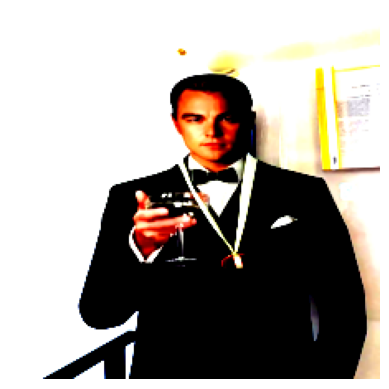

In [11]:
from src.base import BaseModel
from typing import Any


def get_transform(
    img_size: tuple[int] = (224, 224),
    normalize_mean: list[float] = [0.485, 0.456, 0.406],
    normalize_std: list[float] = [0.229, 0.224, 0.225],
):
    return torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean=normalize_mean, std=normalize_std),
            torchvision.transforms.Resize(img_size),
        ]
    )

to_tensor = get_transform()


class DMFC_FAS_Model(BaseModel):
    def __init__(self, model: Any):
        super().__init__(model=model)

    def predict(self, img: Any) -> float:
        live_classid = 1 #label2classid['Live Face']
        
        self.model.eval()
        with torch.no_grad():
            img = to_tensor(img).unsqueeze(0)
            img = img.to(device)
            
            outputs = self.model(img)
            
            score = F.softmax(outputs, dim=1)[:, live_classid]
        return float(score)




i = 1
model = DMFC_FAS_Model(model=net)
pred = model.predict(dataset[i]['img'])
print(pred, type(pred))

plt.imshow(to_tensor(dataset[i]['img']).permute(1, 2, 0))
plt.axis('off');

## Transforms

In [12]:
from src import transforms
from src.base import BaseTransform
import inspect

In [ ]:
list_type_transforms = [
    # Advanced transformations
    [
        transforms.MorphologicalTransform,
        None,
    ],

    # Noise transforms
    [
        transforms.PixelDropoutTransform,
        None,
    ],

    # Color transformations
    [
        transforms.BrightnessContrastTransform,
        transforms.HSVTransform,
        transforms.RGBShiftTransform,
        transforms.GammaTransform,
        transforms.SolarizeTransform,
        transforms.PosterizeTransform,
        transforms.EqualizeTransform,
        transforms.InvertTransform,
        transforms.ToGrayTransform,
        transforms.ChannelShuffleTransform,
        transforms.ToSepiaTransform,
        None,
    ],

    # Transformations of blurring and sharpness
    [
        transforms.BlurTransform,
        transforms.GaussianBlurTransform,
        transforms.MedianBlurTransform,
        transforms.MotionBlurTransform,
        transforms.SharpenTransform,
        transforms.EmbossTransform,
        None,
    ],

    # Weather and atmospheric conditions
    [
        transforms.RainTransform,
        transforms.SnowTransform,
        transforms.RainbowTransform,
        transforms.ChromaticAberrationTransform,
        transforms.DefocusTransform,
        transforms.ZoomBlurTransform,
        None,
    ],

    # Geometric transformations
    [
        transforms.PerspectiveTransform,
        transforms.OpticalDistortionTransform,
        transforms.ShiftScaleRotateTransform,
        None,
    ],

    # Transformation of compression and artifacts
    [
        transforms.CompressionTransform,
        transforms.DownscaleTransform,
        None,
    ],

    # Dropout transforms
    [
        transforms.CoarseDropoutTransform,
        transforms.GridDropoutTransform,
        None,
    ],
]


list_type_transforms[:5]

[[src.transforms.transforms.MorphologicalTransform, None],
 [src.transforms.transforms.PixelDropoutTransform, None],
 [src.transforms.transforms.BrightnessContrastTransform,
  src.transforms.transforms.HSVTransform,
  src.transforms.transforms.RGBShiftTransform,
  src.transforms.transforms.GammaTransform,
  src.transforms.transforms.SolarizeTransform,
  src.transforms.transforms.PosterizeTransform,
  src.transforms.transforms.EqualizeTransform,
  src.transforms.transforms.InvertTransform,
  src.transforms.transforms.ToGrayTransform,
  src.transforms.transforms.ChannelShuffleTransform,
  src.transforms.transforms.ToSepiaTransform,
  None],
 [src.transforms.transforms.BlurTransform,
  src.transforms.transforms.GaussianBlurTransform,
  src.transforms.transforms.MedianBlurTransform,
  src.transforms.transforms.MotionBlurTransform,
  src.transforms.transforms.SharpenTransform,
  src.transforms.transforms.EmbossTransform,
  None],
 [src.transforms.transforms.RainTransform,
  src.transforms.t

## Pipeline

In [14]:
from src.pipeline import PipelineAttackOptunaDataset, PipelineAttackOptunaImg
from src.utils.logging import LoggerOptuna

In [15]:
logger = LoggerOptuna(
    direction=PARAMS['direction'],
    description=PARAMS['description'],
)

# DATASET
optuna_attack_pipeline_dataset = PipelineAttackOptunaDataset(
    model=model,
    list_type_transforms=list_type_transforms,
    logger=logger,
)

optuna_attack_pipeline_dataset.optimize(
    data=dataset,
    direction=PARAMS['direction'],
    n_trials=PARAMS['n_trials'],
    timeout=PARAMS['timeout'],
    show_progress=True,
    catch=(ValueError, ),
)

# IMG
# optuna_attack_pipeline_img = PipelineAttackOptunaImg(
#     model=model,
#     list_type_transforms=list_type_transforms,
#     logger=logger,
# )

# optuna_attack_pipeline_img.optimize(
#     data=dataset[0]['img'],
#     direction=PARAMS['direction'],
#     n_trials=PARAMS['n_trials'],
#     timeout=PARAMS['timeout'],
#     show_progress=True,
#     catch=(ValueError, ),
# )

  0%|          | 0/500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (7, 8) automatically adjusted to (7, 9).
  result = _ensure_odd_values(result, info.field_name)
/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (4, 11) automatically adjusted to (5, 11).
  result = _ensure_odd_values(result, info.field_name)
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (4, 9) automatically adjusted to (5, 9).
  result = _ensure_odd_values(result, info.field_name)
/usr/l

In [16]:
print(os.listdir('/kaggle/working/logs'))

['run_1']


In [17]:
# !zip -FSr run.zip /kaggle/working/logs/run_3

In [18]:
shutil.rmtree('DMFC-FAS')
shutil.rmtree('fas_aug_attack')

NameError: name 'shutil' is not defined